In [97]:
!pip install networkx
!pip install matplotlib
!pip install tqdm
!pip install pandas
!pip install numpy
!pip install graphviz
!pip install scikit-learn

# Task 1. Algorithm's analysis

In [98]:
import time
import random
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, groupby

from networkx.algorithms import tree
from networkx.algorithms import bellman_ford_predecessor_and_distance
from networkx.algorithms import floyd_warshall_predecessor_and_distance

import numpy.typing as npt

### Generating graph

In [99]:

# You can use this function to generate a random graph with 'num_of_nodes'
# nodes and 'completeness' probability of an edge between any two nodes
# If 'directed' is True, the graph will be directed
# If 'draw' is True, the graph will be drawn
def gnp_random_connected_graph(num_of_nodes: int,
                               completeness: int,
                               directed: bool = False,
                               draw: bool = False):
    """
    Generates a random graph, similarly to an Erdős-Rényi
    graph, but enforcing that the resulting graph is conneted
    (in case of undirected graphs)
    """


    if directed:
        G = nx.DiGraph()
    else:
        G = nx.Graph()
    edges = combinations(range(num_of_nodes), 2)
    G.add_nodes_from(range(num_of_nodes))

    for _, node_edges in groupby(edges, key = lambda x: x[0]):
        node_edges = list(node_edges)
        random_edge = random.choice(node_edges)
        if random.random() < 0.5:
            random_edge = random_edge[::-1]
        G.add_edge(*random_edge)
        for e in node_edges:
            if random.random() < completeness:
                G.add_edge(*e)

    for (u,v,w) in G.edges(data=True):
        w['weight'] = random.randint(-5, 20)

    if draw:
        plt.figure(figsize=(10,6))
        if directed:
            # draw with edge weights
            pos = nx.arf_layout(G)
            nx.draw(G,pos, node_color='lightblue',
                    with_labels=True,
                    node_size=500,
                    arrowsize=20,
                    arrows=True)
            labels = nx.get_edge_attributes(G,'weight')
            nx.draw_networkx_edge_labels(G, pos,edge_labels=labels)

        else:
            nx.draw(G, node_color='lightblue',
                with_labels=True,
                node_size=500)

    return G

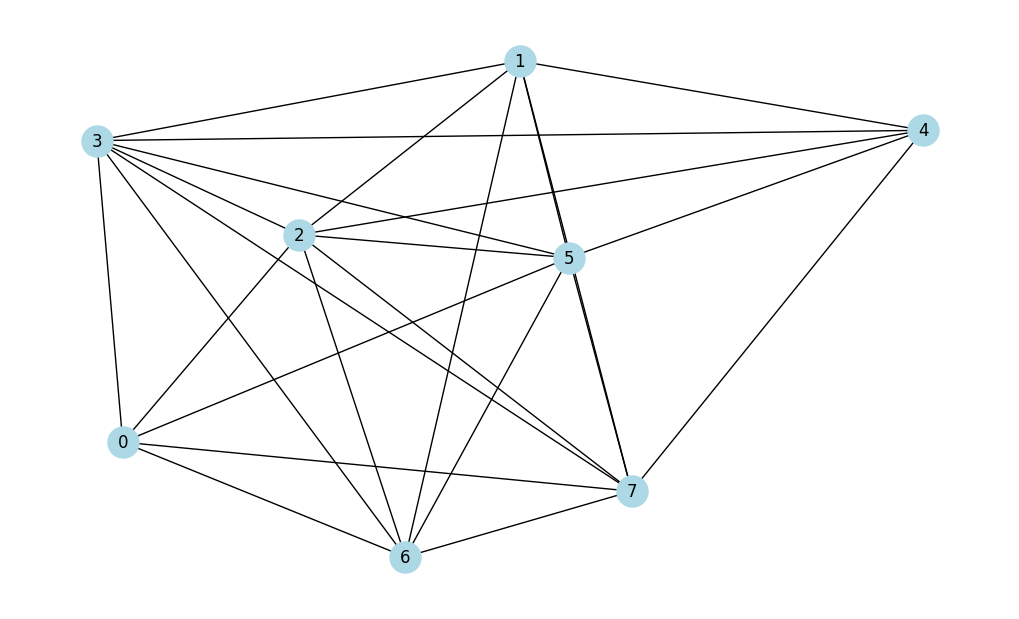

In [100]:
G = gnp_random_connected_graph(8, 0.8, False, True)

## Subtask 1.1 (1 point)

### Kruskal's algorithm

#### nx implementation

In [101]:
mstk = tree.minimum_spanning_tree(G, algorithm="kruskal")

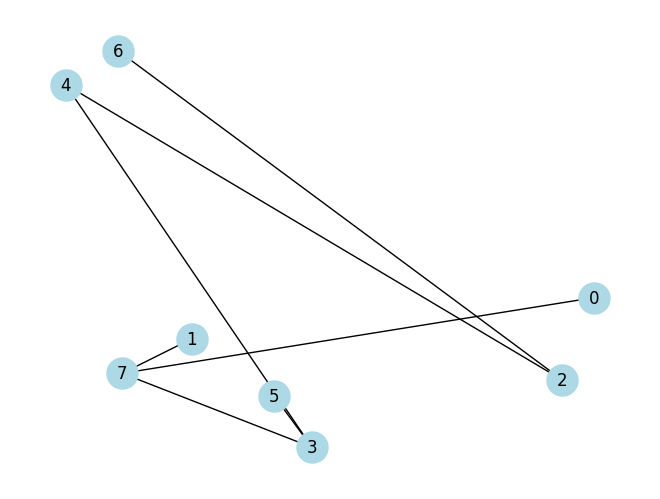

In [102]:
nx.draw(mstk, node_color='lightblue',
        with_labels=True,
        node_size=500)

In [103]:
mstk.edges(), len(mstk.edges())

(EdgeView([(0, 7), (1, 7), (2, 4), (2, 6), (3, 4), (3, 7), (3, 5)]), 7)

#### Our implementation

In [104]:
def kruskal_algorithm(graph):
    """
    Finds the Minimum Spanning Tree (MST) of a graph using Kruskal's algorith

    This function iterates through all edges of the graph, sorted by weight
    and adds them to the MST if they do not form a cycle.
    It uses a disjoint-set data structure logic to track connected components

    :param graph: A NetworkX Graph object containing weighted edges
                  Edges should have a 'weight' attribute
    :return: A new NetworkX Graph object representing the Minimum Spanning Tree
             The returned graph contains the subset of edges that connects
             all vertices with the minimum possible total edge weight
    """
    parent = {}
    parent = {}
    edges = []
    for node in graph.nodes():
        parent[node] = node
    for node1, node2, weight in graph.edges(data='weight'):
        nodes = (node1, node2)
        edges.append((nodes, weight))
    edges.sort(key=lambda x: x[1])

    minimum_spanning_tree = []
    for edge, weight in edges:
        root1 = edge[0]
        while parent[root1] != root1:
            root1 = parent[root1]
        root2 = edge[1]
        while parent[root2] != root2:
            root2 = parent[root2]
        if root1 != root2:
            parent[root1] = root2
            minimum_spanning_tree.append((edge, weight))

    final_mst = nx.Graph()
    for edge, weight in minimum_spanning_tree:
        final_mst.add_edge(edge[0], edge[1], weight=weight)
    return final_mst

### Additional task

In [105]:
def kruskal_algorithm_dsu(graph):
    """
    Implements Kruskal's algorithm to find the Minimum Spanning Tree (MST)
    using the Disjoint Set Union (DSU) data structure

    This implementation employs two key DSU optimizations for efficiency:
    1. Path Compression (in find_root function)
    2. Union by Rank (to balance tree heights during union)

    :param graph: A NetworkX graph object (nx.Graph) with weighted edges
    :return: A new NetworkX graph representing the Minimum Spanning Tree
    """
    parent = {}
    height = {}
    edges = []

    for node in graph.nodes():
        height[node] = 0
        parent[node] = node
    for node1, node2, weight in graph.edges(data='weight'):
        nodes = (node1, node2)
        edges.append((nodes, weight))
    edges.sort(key=lambda x: x[1])

    def find_root(node):
        if parent[node] != node:
            parent[node] = find_root(parent[node])
        return parent[node]

    minimum_spanning_tree = []
    for edge, weight in edges:
        root1 = find_root(edge[0])
        root2 = find_root(edge[1])
        if root1 != root2:
            if height[root1] > height[root2]:
                parent[root2] = root1
            elif height[root1] < height[root2]:
                parent[root1] = root2
            else:
                parent[root2] = root1
                height[root1] += 1
            minimum_spanning_tree.append((edge, weight))

    final_mst = nx.Graph()
    for edge, weight in minimum_spanning_tree:
        final_mst.add_edge(edge[0], edge[1], weight=weight)
    return final_mst

### Prim's algorithm

#### nx implementation

In [106]:
mstp = tree.minimum_spanning_tree(G, algorithm="prim")

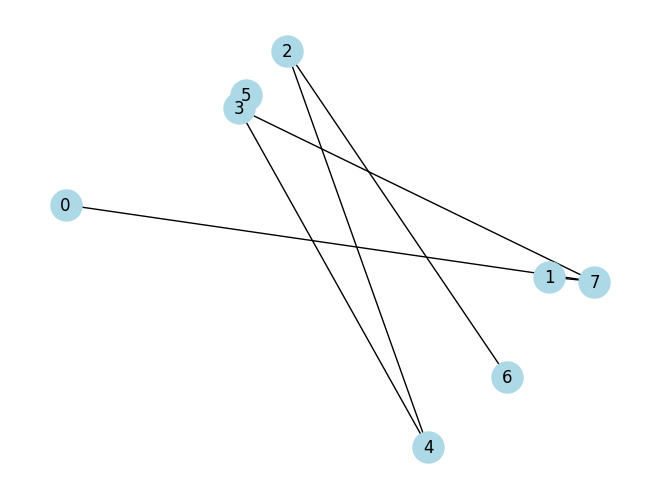

In [107]:
nx.draw(mstp, node_color='lightblue',
        with_labels=True,
        node_size=500)

In [108]:
mstp.edges(), len(mstp.edges())

(EdgeView([(0, 7), (1, 7), (2, 4), (2, 6), (3, 7), (3, 4), (3, 5)]), 7)

#### Your implementation

In [109]:
def prim_algorithm(graph):
    """
    Finds the Minimum Spanning Tree (MST) using Prim's algorithm

    This implementation manually selects the edge with the minimum weight
    from a list of potential edges at each step, ensuring that no cycles
    are formed. It assumes the input graph is connected and edges have weights

    :param graph: A NetworkX Graph object. Edges should have a 'weight' attribute
    :return: A new NetworkX Graph object representing the Minimum Spanning Tree
    """
    visited_nodes = set()
    potential_edge = []
    visited_nodes.add(list(graph.nodes())[0])
    for neighbor, attrs in graph[list(graph.nodes())[0]].items():
        weight = attrs.get('weight', 1)
        potential_edge.append((weight, list(graph.nodes())[0], neighbor))

    spanning_tree = nx.Graph()
    while len(visited_nodes) < len(graph.nodes()):
        edges = []
        for edge in potential_edge:
            if edge[2] in visited_nodes:
                continue
            else:
                edges.append(edge)
        smallets_edge = min(edges, key=lambda x: x[0])
        weight, node1, node2 = smallets_edge
        spanning_tree.add_edge(node1, node2, weight=weight)
        visited_nodes.add(node2)

        for neighbor, attrs in graph[node2].items():
            if neighbor not in visited_nodes:
                new_weight = attrs.get('weight', 1)
                potential_edge.append((new_weight, node2, neighbor))
    return spanning_tree

Comparative performance testing and visualization of the effectiveness of MST construction algorithms:


=== DENSITY TESTING: 0.1 ===
Nodes      | Prim       | Kr         | Kr(DSU)    | NetworkX  
-----------------------------------------------------------------
10         | 0.00004s  | 0.00003s  | 0.00003s  | 0.00006s
20         | 0.00010s  | 0.00005s  | 0.00006s  | 0.00011s
50         | 0.00057s  | 0.00023s  | 0.00020s  | 0.00034s
100        | 0.00331s  | 0.00098s  | 0.00058s  | 0.00094s
200        | 0.02221s  | 0.00837s  | 0.00234s  | 0.00308s
500        | 0.34271s  | 0.16491s  | 0.01409s  | 0.01836s

=== DENSITY TESTING: 0.6 ===
Nodes      | Prim       | Kr         | Kr(DSU)    | NetworkX  
-----------------------------------------------------------------
10         | 0.00009s  | 0.00006s  | 0.00007s  | 0.00011s
20         | 0.00028s  | 0.00016s  | 0.00016s  | 0.00026s
50         | 0.00227s  | 0.00125s  | 0.00098s  | 0.00099s
100        | 0.01529s  | 0.00797s  | 0.00293s  | 0.00354s
200        | 0.12404s  | 0.08116s  | 0.01170s  | 0.01489s
500        | 2.01800s  | 1.94604s  | 0.19122

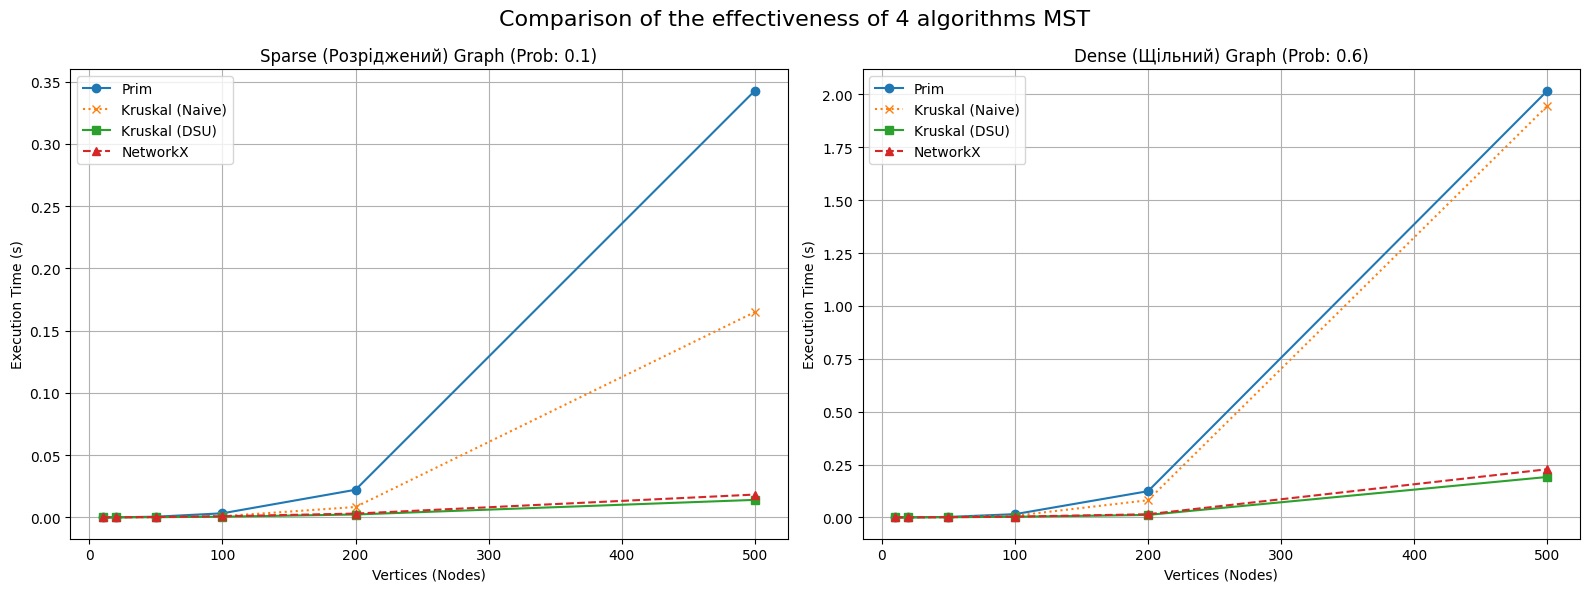

In [110]:
def time_measuring_1_1(algorithm, graph, num_of_runs=5):
    """
    Measures the execution time of a specific graph algorithm over multiple runs

    This function executes the provided algorithm on the given graph multiple times
    to filter out system noise and returns the minimum execution time recorded
    which represents the best-case performance for that environment

    :param algorithm: The function implementing the graph algorithm to be tested
                      Must accept 'graph' as a single argument
    :param graph: The graph object (e.g., networkx.Graph) on which the algorithm runs
    :param num_of_runs: The number of times to execute the algorithm (default is 5)
    :return: The minimum execution time (float) in seconds across all runs
    """
    execution_time = []
    made_tries = 0
    while made_tries <= num_of_runs:
        start = time.time()
        algorithm(graph)
        end = time.time()
        time_measured = end - start
        execution_time.append(time_measured)
        made_tries += 1
    return min(execution_time)

sizes = [10, 20, 50, 100, 200, 500]
density = [0.1, 0.6]
runs = 5
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, prob in enumerate(density):
    print(f"\n=== DENSITY TESTING: {prob} ===")
    print(f"{'Nodes':<10} | {'Prim':<10} | {'Kr':<10} | {'Kr(DSU)':<10} | {'NetworkX':<10}")
    print("-" * 65)
    res_prim = []
    res_kruskal = []
    res_kruskal_dsu = []
    res_nx = []
    for size in sizes:
        try:
            graph = gnp_random_connected_graph(size, prob, directed=False, draw=False)
        except:
            graph = gnp_random_connected_graph(size, prob + 0.15, directed=False, draw=False)

        # 1. Prim
        time_prim = time_measuring_1_1(prim_algorithm, graph, runs)
        res_prim.append(time_prim)

        # 2. Kruskal
        time_kruskal = time_measuring_1_1(kruskal_algorithm, graph, runs)
        res_kruskal.append(time_kruskal)

        # 3. Kruskal DSU
        time_kr_dsu = time_measuring_1_1(kruskal_algorithm_dsu, graph, runs)
        res_kruskal_dsu.append(time_kr_dsu)

        # 4. NetworkX
        time_nx = time_measuring_1_1(lambda g: nx.minimum_spanning_tree(g), graph, runs)
        res_nx.append(time_nx)

        print(f"{size:<10} | {time_prim:.5f}s  | {time_kruskal:.5f}s  | {time_kr_dsu:.5f}s  | {time_nx:.5f}s")

    ax = axes[i]
    ax.plot(sizes, res_prim, label='Prim', marker='o')
    ax.plot(sizes, res_kruskal, label='Kruskal (Naive)', marker='x', linestyle=':')
    ax.plot(sizes, res_kruskal_dsu, label='Kruskal (DSU)', marker='s')
    ax.plot(sizes, res_nx, label='NetworkX', marker='^', linestyle='--')
    graph_type = "Sparse (Розріджений)" if prob < 0.3 else "Dense (Щільний)"
    ax.set_title(f'{graph_type} Graph (Prob: {prob})')
    ax.set_xlabel('Vertices (Nodes)')
    ax.set_ylabel('Execution Time (s)')
    ax.legend()
    ax.grid(True)

plt.suptitle('Comparison of the effectiveness of 4 algorithms MST', fontsize=16)
plt.tight_layout()
plt.show()

### Сonclusions for task 1.1

The leader in terms of speed is Kruskal's algorithm using the Disjoint Set Union (DSU) system, which demonstrates the best performance on both sparse and dense graphs, effectively handling the growth in the number of edges due to the nearly linear complexity of set union operations. 

The NetworkX library implementation shows consistently high performance, only slightly inferior to the optimized Kruskal (DSU) due to internal library overhead, making it a reliable choice for rapid development. In contrast, the implementation of Kruskal's algorithm and Prim's algorithm proved to be significantly less efficient: Prim's algorithm showed the worst time complexity, increasing particularly sharply on dense graphs, while Kruskal suffers from slow cycle checking without DSU optimization. 

That's why it is better to use Kruskal algorithm with DSU or the NetworkX implementation, when working with large graphs.

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

## Subtask 1.2 (1 point)

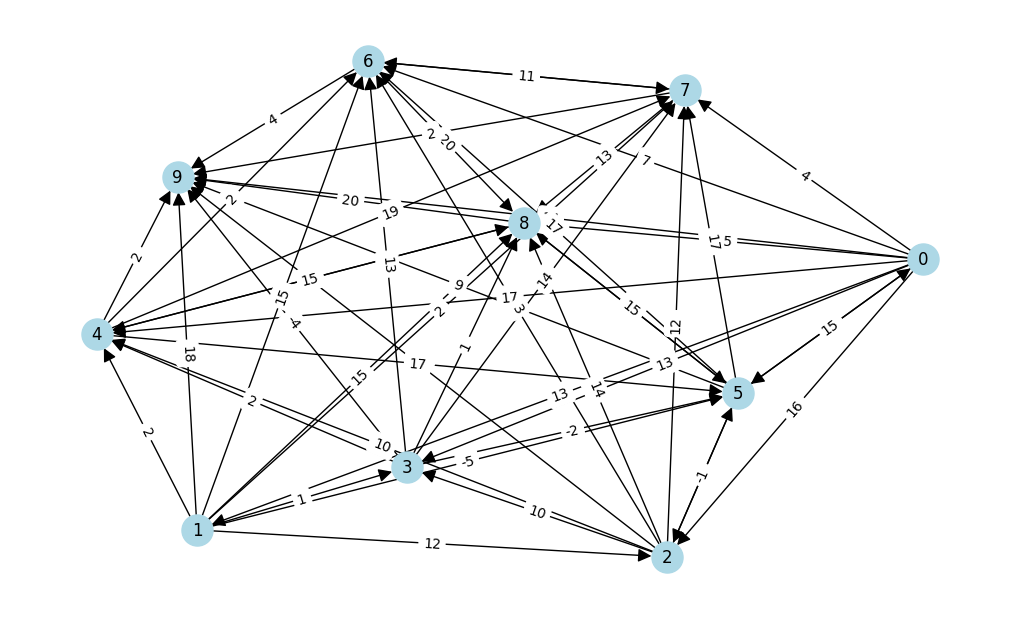

In [111]:
G = gnp_random_connected_graph(10, 1, True, True)

### Bellman-Ford algorithm

#### nx implementation

In [112]:
# pred is a dictionary of predecessors, dist is a dictionary of distances
try:
    pred, dist = bellman_ford_predecessor_and_distance(G, 0)
    for k, v in dist.items():
        print(f"Distance to {k}:", v)
except:
    print("Negative cycle detected")

Distance to 0: 0
Distance to 1: 13
Distance to 2: 2
Distance to 3: 12
Distance to 4: 12
Distance to 5: 3
Distance to 6: 5
Distance to 7: 4
Distance to 8: 13
Distance to 9: 3


#### Our implementation

In [113]:
def bellman_ford_algorithm(G, start_node: int) -> None | dict:
    """
    Computes the shortest path distances from a given start node to all other
    nodes in a weighted directed graph using the Bellman–Ford algorithm

    The algorithm supports graphs with negative edge weights and is capable of
    detecting negative-weight cycles

    Algorithm stops early if no distance updates occur in an iteration

    Returns dictionary with nodes as keys and distance to them as values

    Also if a negative weight cycle was detected returns None instead of dict

    :param G: Weighted graph
    :param start_node: The node from which algorithm starts
    """
    dist = {}

    for node in G.nodes: # Set distances to infinity, meaning that I cant reach a node
        dist[node] = float("inf")

    dist[start_node] = 0

    for _ in range(len(G.nodes)-1): # This algorithm needs at most n-1 iterations
        old_dist = dist.copy()

        for edge in G.edges(data=True):
            v1 = edge[0]
            v2 = edge[1]
            w = edge[2]["weight"]

            dist[v2] = min(dist[v2], dist[v1] + w)

        if old_dist == dist: # Stop, because algorithm has already found the shortest path
            break


    if old_dist != dist:
        return

    return dist

In [114]:
my_dist = bellman_ford_algorithm(G, 0)

if my_dist is None:
    print("Negative cycle detected")
else:
    for k, v in my_dist.items():
        print(f"Distance to {k}:", v)

Distance to 0: 0
Distance to 1: 13
Distance to 2: 2
Distance to 3: 12
Distance to 4: 12
Distance to 5: 3
Distance to 6: 5
Distance to 7: 4
Distance to 8: 13
Distance to 9: 3


### Floyd-Warshall algorithm

#### nx implementation

In [115]:
# pred is a dictionary of predecessors, dist is a dictionary of distances dictionaries
try:
    pred, dist = floyd_warshall_predecessor_and_distance(G)
    for k, v in dist.items():
        print(f"Distances with {k} source:", dict(v))
except:
    print("Negative cycle detected")

Distances with 0 source: {0: 0, 1: 13, 2: 2, 3: 12, 4: 12, 5: 3, 6: 5, 7: 4, 8: 13, 9: 3}
Distances with 1 source: {1: 0, 2: -6, 3: 1, 4: 2, 5: -5, 6: -3, 7: 2, 8: 2, 9: -5, 0: 10}
Distances with 2 source: {2: 0, 3: 10, 4: 10, 5: 7, 6: 3, 7: 12, 8: 11, 9: 1, 0: 22, 1: 35}
Distances with 3 source: {3: 0, 9: -4, 4: 2, 5: -2, 6: 0, 7: 9, 8: 1, 0: 13, 1: 26, 2: -3}
Distances with 4 source: {4: 0, 5: 17, 6: 2, 7: 15, 8: 10, 9: 2, 0: 32, 1: 45, 2: 16, 3: 26}
Distances with 5 source: {5: 0, 0: 15, 2: -1, 6: 2, 7: 11, 8: 10, 9: 0, 1: 28, 3: 9, 4: 9}
Distances with 6 source: {6: 0, 7: 13, 8: 20, 9: 4, 0: 50, 1: 63, 2: 34, 3: 44, 4: 35, 5: 35}
Distances with 7 source: {7: 0, 6: 11, 8: 13, 9: 2, 0: 43, 1: 56, 2: 27, 3: 37, 4: 28, 5: 28}
Distances with 8 source: {8: 0, 4: 15, 5: 15, 9: 15, 0: 30, 1: 43, 2: 14, 3: 24, 6: 17, 7: 26}
Distances with 9 source: {9: 0, 0: inf, 1: inf, 2: inf, 3: inf, 4: inf, 5: inf, 6: inf, 7: inf, 8: inf}


#### Our implementation

In [116]:
def floyd_warshall_algorithm(G) -> None | dict:
    """
    Computes the shortest path distances between all pairs of nodes in a
    weighted directed graph using the Floyd–Warshall algorithm

    The algorithm supports negative edge weights and can detect the presence
    of negative-weight cycles

    Returns a 2D distance matrix where dist[i][j] represents the shortest
    path distance from node i to node j

    Also Returns None if a negative-weight cycle is detected

    :param G: Weighted graph
    """
    n = len(G.nodes) # number of nodes in a graph G

    # Set up a distance matrix
    dist = [[float("inf") for _ in range(n)] for _ in range(n)]

    for i in range(n):
        dist[i][i] = 0

    for edge in G.edges(data=True):
        dist[edge[0]][edge[1]] = edge[2]["weight"]

    # Algorithm implimintation
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if dist[i][j] > dist[i][k] + dist[k][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]

    for i in range(n):
        if dist[i][i] != 0:
            return

    return dist

In [117]:
my_dist = floyd_warshall_algorithm(G)

if my_dist is None:
    print("Negative cycle detected")
else:
    for i, row in enumerate(my_dist):
        print(f"Distances with {i} source: {", ".join([f"{j}: {el}" for j, el in enumerate(row)])}")


Distances with 0 source: 0: 0, 1: 13, 2: 2, 3: 12, 4: 12, 5: 3, 6: 5, 7: 4, 8: 13, 9: 3
Distances with 1 source: 0: 10, 1: 0, 2: -6, 3: 1, 4: 2, 5: -5, 6: -3, 7: 2, 8: 2, 9: -5
Distances with 2 source: 0: 22, 1: 35, 2: 0, 3: 10, 4: 10, 5: 7, 6: 3, 7: 12, 8: 11, 9: 1
Distances with 3 source: 0: 13, 1: 26, 2: -3, 3: 0, 4: 2, 5: -2, 6: 0, 7: 9, 8: 1, 9: -4
Distances with 4 source: 0: 32, 1: 45, 2: 16, 3: 26, 4: 0, 5: 17, 6: 2, 7: 15, 8: 10, 9: 2
Distances with 5 source: 0: 15, 1: 28, 2: -1, 3: 9, 4: 9, 5: 0, 6: 2, 7: 11, 8: 10, 9: 0
Distances with 6 source: 0: 50, 1: 63, 2: 34, 3: 44, 4: 35, 5: 35, 6: 0, 7: 13, 8: 20, 9: 4
Distances with 7 source: 0: 43, 1: 56, 2: 27, 3: 37, 4: 28, 5: 28, 6: 11, 7: 0, 8: 13, 9: 2
Distances with 8 source: 0: 30, 1: 43, 2: 14, 3: 24, 4: 15, 5: 15, 6: 17, 7: 26, 8: 0, 9: 15
Distances with 9 source: 0: inf, 1: inf, 2: inf, 3: inf, 4: inf, 5: inf, 6: inf, 7: inf, 8: inf, 9: 0


Comparative analysis of algorithm performance: Bellman-Ford and Floyd-Warshall


=== DENSITY TESTING: 0.2 ===
Nodes      | Bellman-Ford (All)   | Floyd-Warshall       | NetworkX (Lib)      
--------------------------------------------------------------------------------
10         | 0.00031s             | 0.00026s             | 0.00036s
20         | 0.00407s             | 0.00185s             | 0.00240s
30         | 0.01443s             | 0.00531s             | 0.00772s
50         | 0.05237s             | 0.02383s             | 0.02937s
80         | 0.13754s             | 0.04311s             | 0.05368s

=== DENSITY TESTING: 0.8 ===
Nodes      | Bellman-Ford (All)   | Floyd-Warshall       | NetworkX (Lib)      
--------------------------------------------------------------------------------
10         | 0.00069s             | 0.00012s             | 0.00018s
20         | 0.00479s             | 0.00078s             | 0.00100s
30         | 0.01761s             | 0.00243s             | 0.00316s
50         | 0.07925s             | 0.01024s             | 0.01327s
80    

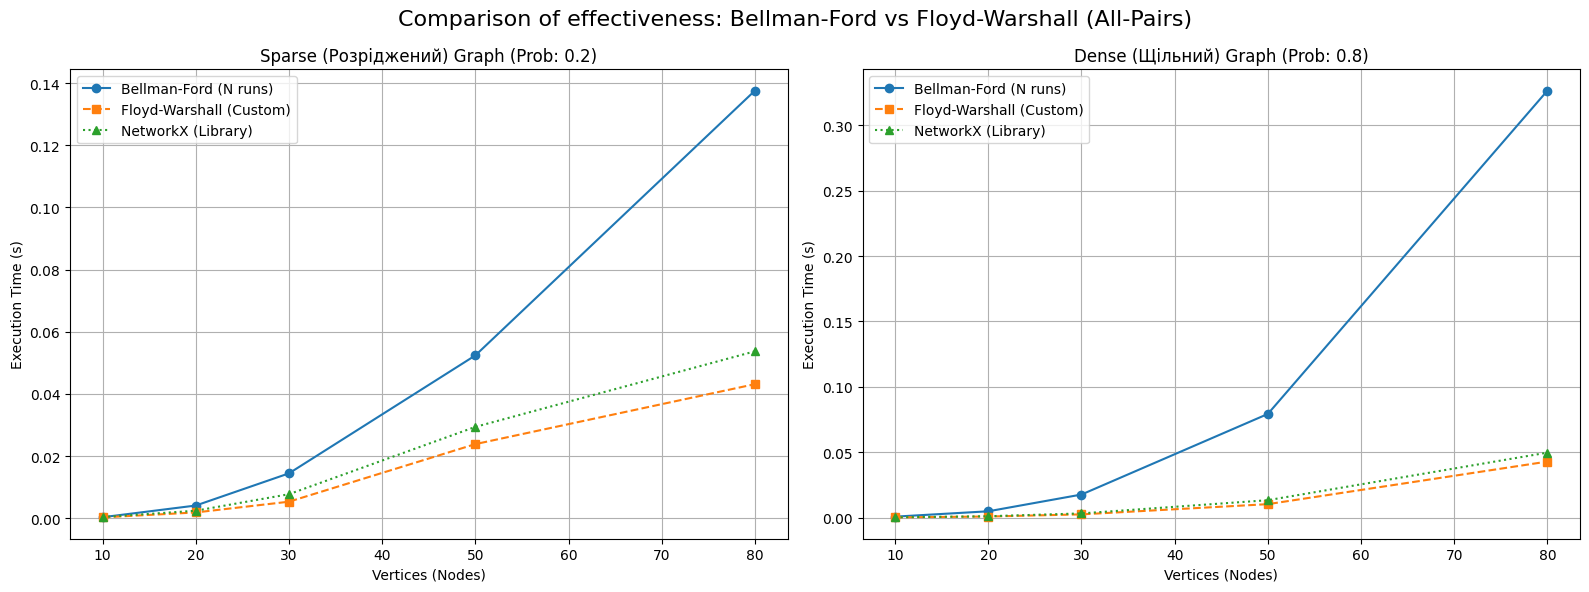

In [118]:
def time_measuring_1_2(algorithm, graph, num_of_runs=3):
    """
    Measures the execution time of a specific graph algorithm over multiple runs.
    """
    execution_time = []
    made_tries = 0
    while made_tries < num_of_runs:
        start = time.time()
        algorithm(graph)
        end = time.time()
        time_measured = end - start
        execution_time.append(time_measured)
        made_tries += 1
    return min(execution_time)

def bellman_ford_all_pairs(graph):
    for node in graph.nodes():
        bellman_ford_algorithm(graph, node)

sizes = [10, 20, 30, 50, 80]
density = [0.2, 0.8]
runs = 3
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, prob in enumerate(density):
    print(f"\n=== DENSITY TESTING: {prob} ===")
    print(f"{'Nodes':<10} | {'Bellman-Ford (All)':<20} | {'Floyd-Warshall':<20} | {'NetworkX (Lib)':<20}")
    print("-" * 80)
    res_bf = []
    res_fw = []
    res_nx = []
    for size in sizes:
        graph = nx.gnp_random_graph(size, prob, directed=True)
        for (u, v) in graph.edges():
            graph.edges[u,v]['weight'] = random.randint(1, 10)

        # 1. Bellman-Ford
        time_bf = time_measuring_1_2(bellman_ford_all_pairs, graph, runs)
        res_bf.append(time_bf)

        # 2. Floyd-Warshall
        time_fw = time_measuring_1_2(floyd_warshall_algorithm, graph, runs)
        res_fw.append(time_fw)

        # 3. NetworkX Floyd-Warshall
        time_nx = time_measuring_1_2(lambda g: nx.floyd_warshall(g, weight='weight'), graph, runs)
        res_nx.append(time_nx)

        print(f"{size:<10} | {time_bf:.5f}s             | {time_fw:.5f}s             | {time_nx:.5f}s")

    ax = axes[i]
    ax.plot(sizes, res_bf, label='Bellman-Ford (N runs)', marker='o', linestyle='-')
    ax.plot(sizes, res_fw, label='Floyd-Warshall (Custom)', marker='s', linestyle='--')
    ax.plot(sizes, res_nx, label='NetworkX (Library)', marker='^', linestyle=':')

    graph_type = "Sparse (Розріджений)" if prob < 0.5 else "Dense (Щільний)"
    ax.set_title(f'{graph_type} Graph (Prob: {prob})')
    ax.set_xlabel('Vertices (Nodes)')
    ax.set_ylabel('Execution Time (s)')
    ax.legend()
    ax.grid(True)

plt.suptitle('Comparison of effectiveness: Bellman-Ford vs Floyd-Warshall (All-Pairs)', fontsize=16)
plt.tight_layout()
plt.show()

### Сonclusions for task 1.2

The comparison shows that the Floyd-Warshall algorithm demonstrates significantly higher performance and stability compared to multiple executions of the Bellman-Ford algorithm. The chart showing the dependence of time on the number of vertices illustrates that the execution time of the Bellman-Ford algorithm depends on the density of the graph, increasing fastly with an increase in the number of edges (transition from density 0.2 to 0.8), while Floyd-Warshall's algorithm remains almost insensitive to changes in density. 

The comparison of our implementation of Floyd-Warshall with the NetworkX implementation showed the high efficiency of our own code, which even slightly outperformed the library analogue. Also, as a side note, NetworkX Floyd-Warshall algorithm can not detect cycles with negative lenght.

### Testing algorithms on graphs with negative weight edges and negative length cycles:


=== FULL TESTING: NEGATIVE WEIGHTS AND CYCLES ===

 Graph with negative edge (without negative cycle):
  -> Bellman-Ford ('A'->'C'): 3 (3 excpected)
  -> FW Error: list indices must be integers or slices, not str
  -> NetworkX Check: 3

 Graph with negative Cycle:
  -> Bellman-Ford: None (None excpected)
  -> FW Error: list indices must be integers or slices, not str
  -> NetworkX: CAUGHT ERROR: NetworkXUnbounded (Correct behavior)


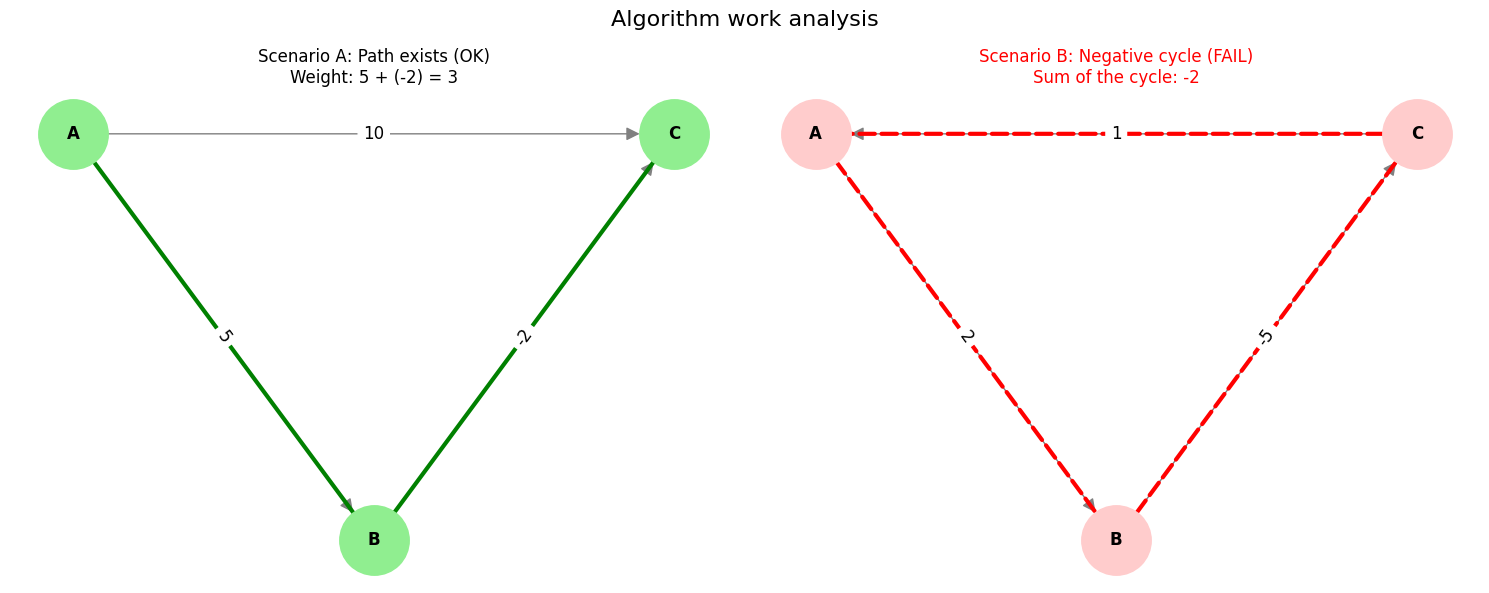

In [119]:
def run_full_stress_test_visualized():
    print(f"\n=== FULL TESTING: NEGATIVE WEIGHTS AND CYCLES ===")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Negative weight
    ax1 = axes[0]
    G_valid = nx.DiGraph()
    G_valid.add_edge('A', 'B', weight=5)
    G_valid.add_edge('B', 'C', weight=-2)
    G_valid.add_edge('A', 'C', weight=10)

    print("\n Graph with negative edge (without negative cycle):")

    # Bellman-Ford
    try:
        bf_res = bellman_ford_algorithm(G_valid, 'A')
        print(f"  -> Bellman-Ford ('A'->'C'): {bf_res['C']} (3 excpected)")
    except Exception as e: print(f"  -> BF Error: {e}")

    #Floyd-Warshall
    try:
        fw_res = floyd_warshall_algorithm(G_valid)
        print(f"  -> Floyd-Warshall ('A'->'C'): {fw_res['A']['C']} (3 expected)")
    except Exception as e: print(f"  -> FW Error: {e}")

    # 3. NetworkX
    try:
        nx_res = nx.bellman_ford_path_length(G_valid, 'A', 'C')
        print(f"  -> NetworkX Check: {nx_res}")
    except Exception as e: print(f"  -> NX Error: {e}")

    pos1 = {'A': (0, 1), 'B': (1, 0), 'C': (2, 1)}
    nx.draw(G_valid, pos1, ax=ax1, with_labels=True, node_color='lightgreen',
            node_size=2500, font_weight='bold', edge_color='gray', arrowsize=20)
    nx.draw_networkx_edges(G_valid, pos1, ax=ax1, edgelist=[('A', 'B'), ('B', 'C')],
                           edge_color='green', width=3, arrowsize=25)
    nx.draw_networkx_edge_labels(G_valid, pos1, ax=ax1, edge_labels=nx.get_edge_attributes(G_valid, 'weight'), font_size=12)
    ax1.set_title("Scenario А: Path exists (OK)\nWeight: 5 + (-2) = 3", fontsize=12)

    # Scenario B: Negative cycle (Error)
    ax2 = axes[1]
    G_cycle = nx.DiGraph()
    G_cycle.add_edge('A', 'B', weight=2)
    G_cycle.add_edge('B', 'C', weight=-5)
    G_cycle.add_edge('C', 'A', weight=1)

    print("\n Graph with negative Cycle:")

    # 1. Bellman-Ford
    try:
        bf_cycle = bellman_ford_algorithm(G_cycle, 'A')
        print(f"  -> Bellman-Ford: {bf_cycle} (None excpected)")
    except Exception as e: print(f"  -> BF Error: {e}")

    # 2. Floyd-Warshall
    try:
        fw_cycle = floyd_warshall_algorithm(G_cycle)
        print(f"  -> Floyd-Warshall: {fw_cycle} (None excpected)")
    except Exception as e: print(f"  -> FW Error: {e}")

    # 3. NetworkX
    print("  -> NetworkX: ", end="")
    try:
        nx.bellman_ford_path(G_cycle, 'A', 'C')
        print("Path found (Unexpected)")
    except nx.NetworkXUnbounded:
        print("CAUGHT ERROR: NetworkXUnbounded (Correct behavior)")
    except Exception as e:
        print(f"Error: {e}")

    pos2 = {'A': (0, 1), 'B': (1, 0), 'C': (2, 1)}
    nx.draw(G_cycle, pos2, ax=ax2, with_labels=True, node_color='#ffcccc',
            node_size=2500, font_weight='bold', edge_color='gray', arrowsize=20)
    nx.draw_networkx_edges(G_cycle, pos2, ax=ax2, edgelist=[('A', 'B'), ('B', 'C'), ('C', 'A')],
                           edge_color='red', width=3, style='dashed', arrowsize=25)
    nx.draw_networkx_edge_labels(G_cycle, pos2, ax=ax2, edge_labels=nx.get_edge_attributes(G_cycle, 'weight'), font_size=12)
    ax2.set_title(f"Scenario B: Negative cycle (FAIL)\nSum of the cycle: -2", fontsize=12, color='red')

    plt.suptitle("Algorithm work analysis", fontsize=16)
    plt.tight_layout()
    plt.show()

run_full_stress_test_visualized()

### Conclusions on testing algorithms with graphs with negative edges and negative cycles: 

The Bellman-Ford and Floyd-Warshall algorithms work correctly with graphs containing edges with negative weights, ensuring that the optimal path is found. However, when working with negative cycles, both algorithms signal that a solution is impossible: Bellman-Ford effectively detects such a cycle on the n-th iteration (returning None), while the classic implementation of Floyd-Warshall in NetworkX does not generate an error automatically, since identifying a cycle using this method requires additional checking for negative values on the main diagonal of the distance matrix.

### Final conclusions for task 1

During our research, a comparative analysis was conducted of our own implementations of algorithms for finding the minimum spanning tree (Prim, Kruskal) and shortest paths (Bellman-Ford, Floyd-Warshall) with the reference methods of the NetworkX library on graphs of varying density and dimension (from 10 to 500 vertices). 

We were able to confirm that our own implementations work correctly, producing results identical to those of NetworkX, in particular when working with negative edge weights and identifying negative cycles. Our own algorithms demonstrated the best performance on sparse graphs of small and medium dimensions (up to 100–200 vertices), while on large dense graphs, the built-in NetworkX functions proved to be faster due to internal optimizations. In particular, Kruskal's algorithm using DSU showed a significant advantage, and Bellman-Ford confirmed its reliability in diagnosing negative cycles, making these approaches optimal for solving specific problems in complex network topologies.

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

# Task 2. Decision Tree Classifier

In [120]:
# scikit-learn package
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split

### Our implementation

In [121]:
class Node:
    def __init__(self, X: npt.NDArray, y: npt.NDArray):
        """
        :param X: numpy array of form [[feature1,feature2, ... featureN], ...] (i.e. [[1.5, 5.4, 3.2, 9.8] , ...] for case with iris d.s.)
        :param y: numpy array of from [class1, class2, ...] (i.e. [0,1,1,2,1,0,...] for case with iris d.s.)
        """

        self.X = X
        self.y = y
        self.feature_index = 0
        self.threshold = 0
        self.left = None
        self.right = None

    def get_probabilities(self, number_of_classes, alpha=1):
        """
        Computes class probability distribution for the samples stored in the node using Laplace smoothing
        """
        y = list(self.y)
        counts = [y.count(i) for i in range(number_of_classes)]
        total_samples = len(y)

        # Used laplace smoothing for finding probabilities of flower types
        probabilities = [(count + alpha)/(total_samples + alpha * number_of_classes) for count in counts]

        return probabilities

In [122]:
class DecisionTreeClassifier:
    def __init__(self, max_depth: int) -> None:
        self.max_depth = max_depth
        self.tree = None
        self.number_of_classes = None



    def fit(self, X: npt.NDArray, y: npt.NDArray) -> None:
        """
        Basically, function that performs all the training (building of a tree)
        We recommend to use it as a wrapper of recursive building function
        """
        self.number_of_classes = np.unique(y).size
        self.tree = self.build_tree(X, y)

    def build_tree(self, X, y, curr_depth=0):
        """
        Recursively builds the decision tree by selecting the best split at each node
        based on information gain
        """
        if curr_depth <= self.max_depth and len(np.unique(y)) > 1:
            best_split = self.get_best_split(X, y)

            if best_split["info_gain"] > 0:
                left_subtree = self.build_tree(best_split["left"][0], best_split["left"][1], curr_depth+1)
                right_subtree = self.build_tree(best_split["right"][0], best_split["right"][1], curr_depth+1)

                node = Node(X, y)
                node.feature_index = best_split["feature_index"]
                node.threshold = best_split["threshold"]
                node.left = left_subtree
                node.right = right_subtree

                return node

        return Node(X, y)


    def get_best_split(self, X, y):
        """
        Finds the best feature and threshold to split the dataset that maximizes information gain
        """
        best_split = {} # Dictionary with best_splits
        max_info_gain = -float("inf")

        # Iterate through all features
        for feature_index in range(len(X[0])):
            feature_values = X[:, feature_index]
            possible_thresholds = np.unique(feature_values)

            # Iterate through all values in a feature
            for threshold in possible_thresholds:
                # Create a boolean mask to keep X and y together
                left_ids, right_ids = self.get_split(X, feature_index, threshold)

                if len(left_ids) > 0 and len(right_ids) > 0: # If split was successful
                    X_left, X_right = X[left_ids], X[right_ids]
                    y_left, y_right = y[left_ids], y[right_ids]

                    curr_info_gain = self.compute_gini(y, y_left, y_right)

                    if curr_info_gain > max_info_gain:
                        best_split["feature_index"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["left"] = (X_left, y_left)
                        best_split["right"] = (X_right, y_right)
                        best_split["info_gain"] = curr_info_gain

                        max_info_gain = curr_info_gain

        return best_split

    def get_split(self, X, feature_index, threshold):
        """Splits the dataset into left and right subsets based on a feature threshold"""
        left_ids = X[:, feature_index] <= threshold
        right_ids = X[:, feature_index] > threshold

        return left_ids, right_ids

    def compute_gini(self, y, y_left, y_right):
        """Computes information gain based on Gini impurity"""
        weight_left = len(y_left) / len(y)
        weight_right = len(y_right) / len(y)

        def gini_index(array):
            """Computes the Gini impurity for a set of class labels"""
            classes = np.unique(array)
            gini = 0

            for cls in classes:
                p_cls = len(array[array == cls]) / len(array) # maybe y == cls???
                gini += p_cls ** 2

            return 1 - gini

        return gini_index(y) - (weight_left * gini_index(y_left) + weight_right * gini_index(y_right))



    def predict(self, X_test: npt.NDArray) -> list:
        """
        Traverse the tree while there is a child
        and return the predicted class for it
        """
        def make_prediction(x, tree):
            """Recursively traverses the tree to produce a prediction for a single sample"""
            if tree.left is None and tree.right is None:
                probabilities = tree.get_probabilities(self.number_of_classes)

                return random.choices([i for i in range(self.number_of_classes)], probabilities, k=1)[0]

                # return tree.calculate_value(self.number_of_classes)

            feature_value = x[tree.feature_index]

            if feature_value <= tree.threshold:
                return make_prediction(x, tree.left)
            return make_prediction(x, tree.right)

        return [make_prediction(x, self.tree) for x in X_test]


    def evaluate(self, X_test: list[list], y_test: list) -> float:
        """
        Returns accuracy of the model (ratio of right guesses to the number of samples)
        """
        y_predictions = self.predict(X_test)
        count_correct = 0

        for i, actual_value in enumerate(y_test):
            if y_predictions[i] == actual_value:
                count_correct += 1

        return count_correct/len(y_test)

In [123]:
# Testing

clf = DecisionTreeClassifier(10)
iris = load_iris()

X, y = iris.data, iris.target

X, X_test, y, y_test = train_test_split(X, y, test_size= 0.20)
X_test.shape, y_test.shape

clf.fit(X, y)

print(f"Accuracy: {clf.evaluate(X_test, y_test)}")

Accuracy: 0.8666666666666667


### Сonclusions for task 2

We implemented a Decision tree classifier. Decision tree is based on this principles: 

 - Recursion - used in a build_tree function, to build a tree (splits data in two parts and than builds further, until some conditions are met)
 - Gini - the index of node "purity", used to pick the treshold and the feature on what we will be splitting
 - Laplace smoothing - used in get_probabilities function to avoid 0% and 100% certainty in type of flower (laplace smoothing is necessary in order for the algorithm to be too strict in the choice and to allow exceptions (like in a real world))

 How it works: first the model is trained with some data by using "fit" function to which we pass X (features of the the flower) and y (all of the flower classes). Then fit function calls build_tree function which recursively builds the tree (building works like this: first we check if node is pure, than we find the best feature to split using get_best_split function and last we split the tree (continue recursion)). When we have built the tree it means that we have trained our model. After that we can check its accuracy by calling evaluate function and passing testing data in it.